<a href="https://colab.research.google.com/github/nblalock14/Capstone1_DataScience/blob/main/Capstone_1_Nick_Blalock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
!wget https://www.fhfa.gov/hpi/download/monthly/hpi_master.csv

--2026-09-30 02:44:09--  https://www.fhfa.gov/hpi/download/monthly/hpi_master.csv
Resolving www.fhfa.gov (www.fhfa.gov)... 54.92.167.213
Connecting to www.fhfa.gov (www.fhfa.gov)|54.92.167.213|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 17156076 (16M) [text/csv]
Saving to: ‘hpi_master.csv.1’

hpi_master.csv.1    100%[===================>]  16.36M  23.0MB/s    in 0.7s    

2026-09-30 02:44:10 (23.0 MB/s) - ‘hpi_master.csv.1’ saved [17156076/17156076]



In [21]:
import pandas as pd

df = pd.read_csv("hpi_master.csv")

print("Minimum year:", df["yr"].min())
print("Maximum year:", df["yr"].max())

Minimum year: 1975
Maximum year: 2026


/tmp/ipykernel_2876/748309281.py:3: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("hpi_master.csv")


# Part 1: Understanding the Data

## FHFA House Price Index Data

### When was the data acquired?

The dataset used in this analysis is the Federal Housing Finance Agency (FHFA) House Price Index Master Dataset. The data in the dataset extends from **1975 through 2026**. The quarterly observations extend through the **second quarter of 2026**, while the monthly observations extend through **July 2026**. The dataset was accessed and downloaded from the FHFA website on **September 11, 2026**.

### Where was the data acquired?

The data was acquired directly from the **Federal Housing Finance Agency (FHFA) House Price Index website**. The Master HPI dataset combines multiple House Price Index series into one dataset and contains housing-price information from geographic areas throughout the United States.

The geographic levels represented in the dataset include the **United States and Census Divisions, states, Metropolitan Statistical Areas (MSAs), and Puerto Rico**.

### How was the data acquired?

The FHFA House Price Index is created using housing transaction data to measure changes in single-family home prices over time. FHFA primarily uses a repeat-sales methodology, which compares price changes for the same properties when they are sold or valued at different points in time.

Different versions of the House Price Index use different sources of housing information. For example, the purchase-only index uses home sales associated with mortgages purchased or securitized by Fannie Mae and Freddie Mac, while other versions of the index incorporate additional appraisal and housing transaction information.

### What are the attributes of this dataset?

The FHFA Master House Price Index dataset contains **12 attributes**.

| Attribute | Description | Type |
|---|---|---|
| `hpi_type` | Identifies the type of House Price Index series, such as traditional, non-metro, manufactured, distress-free, or developmental. | Nominal |
| `hpi_flavor` | Identifies the version of the HPI, such as purchase-only, all-transactions, or expanded-data. | Nominal |
| `frequency` | Indicates whether the observation is reported monthly or quarterly. | Nominal |
| `level` | Identifies the geographic level represented by the observation, such as State, MSA, Puerto Rico, or U.S./Census Division. | Nominal |
| `place_name` | Name of the geographic area represented by the observation. | Nominal |
| `place_id` | Identification code assigned to the geographic area. | Nominal |
| `yr` | Year in which the observation occurred. | Interval |
| `period` | Identifies the month or quarter within the year. | Ordinal |
| `index_nsa` | House Price Index value that has not been seasonally adjusted. | Interval |
| `index_sa` | House Price Index value that has been seasonally adjusted. | Interval |
| `rstderr` | Relative standard error associated with applicable House Price Index estimates. | Ratio |
| `note` | Additional notes or information associated with certain observations. | Nominal |

### What type of data do these attributes contain?

The dataset contains nominal, ordinal, interval, and ratio data.

The variables `hpi_type`, `hpi_flavor`, `frequency`, `level`, `place_name`, `place_id`, and `note` are **nominal** because they identify categories, locations, or labels without a meaningful numerical order.

The `period` variable is **ordinal** because months and quarters occur in a specific sequence.

The `yr` variable is **interval** because differences between years are meaningful, but there is no meaningful true zero. The `index_nsa` and `index_sa` variables are also treated as **interval** data because they measure changes relative to an index base rather than having a true zero point.

The `rstderr` variable is **ratio** data because a value of zero represents no relative standard error and differences and ratios between values are meaningful.



In [22]:
df.head()

,hpi_type,hpi_flavor,frequency,level,place_name,place_id,yr,period,index_nsa,index_sa,rstderr,note
0,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,1,100.00,100.00,NaN,NaN
1,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,2,100.87,100.86,NaN,NaN
2,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,3,101.32,100.89,NaN,NaN
3,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,4,101.73,100.96,NaN,NaN
4,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,5,102.32,101.30,NaN,NaN


In [23]:
df.shape

(186021, 12)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186021 entries, 0 to 186020
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   hpi_type    186021 non-null  object 
 1   hpi_flavor  186021 non-null  object 
 2   frequency   186021 non-null  object 
 3   level       186021 non-null  object 
 4   place_name  186021 non-null  object 
 5   place_id    186021 non-null  object 
 6   yr          186021 non-null  int64  
 7   period      186021 non-null  int64  
 8   index_nsa   186021 non-null  float64
 9   index_sa    96124 non-null   float64
 10  rstderr     58220 non-null   float64
 11  note        58220 non-null   object 
dtypes: float64(3), int64(2), object(7)
memory usage: 17.0+ MB


# Part 2: Data Summary & Initial Insights

In [25]:
numeric_cols = ["index_nsa", "index_sa", "rstderr"]

summary_stats = pd.DataFrame({
    "Mean": df[numeric_cols].mean(),
    "Median": df[numeric_cols].median(),
    "Mode": df[numeric_cols].mode().iloc[0],
    "Minimum": df[numeric_cols].min(),
    "Maximum": df[numeric_cols].max(),
    "Range": df[numeric_cols].max() - df[numeric_cols].min(),
    "Standard Deviation": df[numeric_cols].std()
})

summary_stats.round(2)

,Mean,Median,Mode,Minimum,Maximum,Range,Standard Deviation
index_nsa,199.98,172.13,100.0,18.60,1326.94,1308.34,116.14
index_sa,216.69,187.22,100.0,72.78,1043.20,970.42,113.53
rstderr,2.67,2.05,0.0,0.00,15.75,15.75,2.22


### Summary Statistics Observations

The House Price Index values show substantial variation across the dataset. The mean `index_nsa` is approximately 199.98, while the median is 172.13, indicating that some higher index values pull the average upward. The seasonally adjusted index shows a similar pattern.

The relative standard error has a mean of 2.67, which provides information about the precision of certain HPI estimates rather than directly measuring housing-market performance.

In [26]:
df["frequency"].value_counts()

,count
frequency,
quarterly,181751
monthly,4270


In [27]:
df["level"].value_counts()

,count
level,
MSA,145480
State,30912
USA or Census Division,9382
Puerto Rico,247


In [28]:
nominal_cols = [
    "hpi_type",
    "hpi_flavor",
    "frequency",
    "level",
    "place_name",
    "place_id",
]

nominal_summary = pd.DataFrame({
    "Unique Values": df[nominal_cols].nunique(),
    "Mode": [df[col].mode().iloc[0] for col in nominal_cols]
})

nominal_summary

,Unique Values,Mode
hpi_type,5,traditional
hpi_flavor,3,all-transactions
frequency,2,quarterly
level,4,MSA
place_name,472,United States
place_id,472,USA


In [29]:
missing_values = pd.DataFrame({
    "Missing Values": df.isna().sum(),
    "Percent Missing": (df.isna().sum() / len(df)) * 100
})

missing_values.round(2)

,Missing Values,Percent Missing
hpi_type,0,0.00
hpi_flavor,0,0.00
frequency,0,0.00
level,0,0.00
place_name,0,0.00
place_id,0,0.00
yr,0,0.00
period,0,0.00
index_nsa,0,0.00
index_sa,89897,48.33


### Missing Value Observations

The dataset contains no missing values for most of its attributes. However, `index_sa` is missing approximately **48.33%** of its observations, while `rstderr` and `note` are each missing approximately **68.70%** of their observations.

These missing values should not automatically be replaced with zero because zero would represent an actual numerical value rather than unavailable information. For an analysis that specifically requires seasonally adjusted HPI data, observations without an `index_sa` value could be excluded from that particular analysis. Missing values in the `note` column are less concerning because a blank note may simply indicate that no additional information was necessary for that observation.

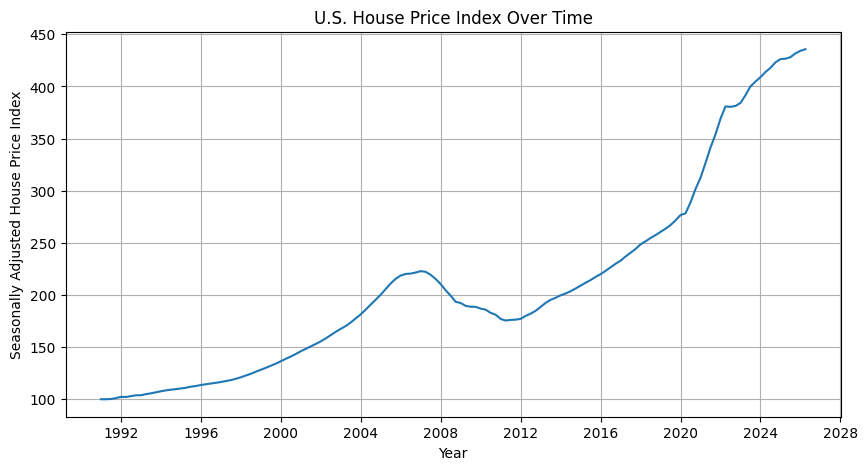

In [30]:
import matplotlib.pyplot as plt

us_hpi = df[
    (df["hpi_type"] == "traditional") &
    (df["hpi_flavor"] == "purchase-only") &
    (df["frequency"] == "quarterly") &
    (df["level"] == "USA or Census Division") &
    (df["place_name"] == "United States")
].copy()

us_hpi["date"] = pd.PeriodIndex(
    us_hpi["yr"].astype(str) + "Q" + us_hpi["period"].astype(str),
    freq="Q"
).to_timestamp()

us_hpi = us_hpi.sort_values("date")

plt.figure(figsize=(10, 5))

plt.plot(us_hpi["date"], us_hpi["index_sa"])

plt.title("U.S. House Price Index Over Time")
plt.xlabel("Year")
plt.ylabel("Seasonally Adjusted House Price Index")
plt.grid(True)

plt.show()

### U.S. House Price Index Over Time

The U.S. House Price Index shows a clear long-term upward trend, meaning residential property values have generally increased over time. The rate of growth is not constant, however, and certain periods show much faster appreciation than others. This demonstrates that housing-market performance changes significantly across different economic periods.

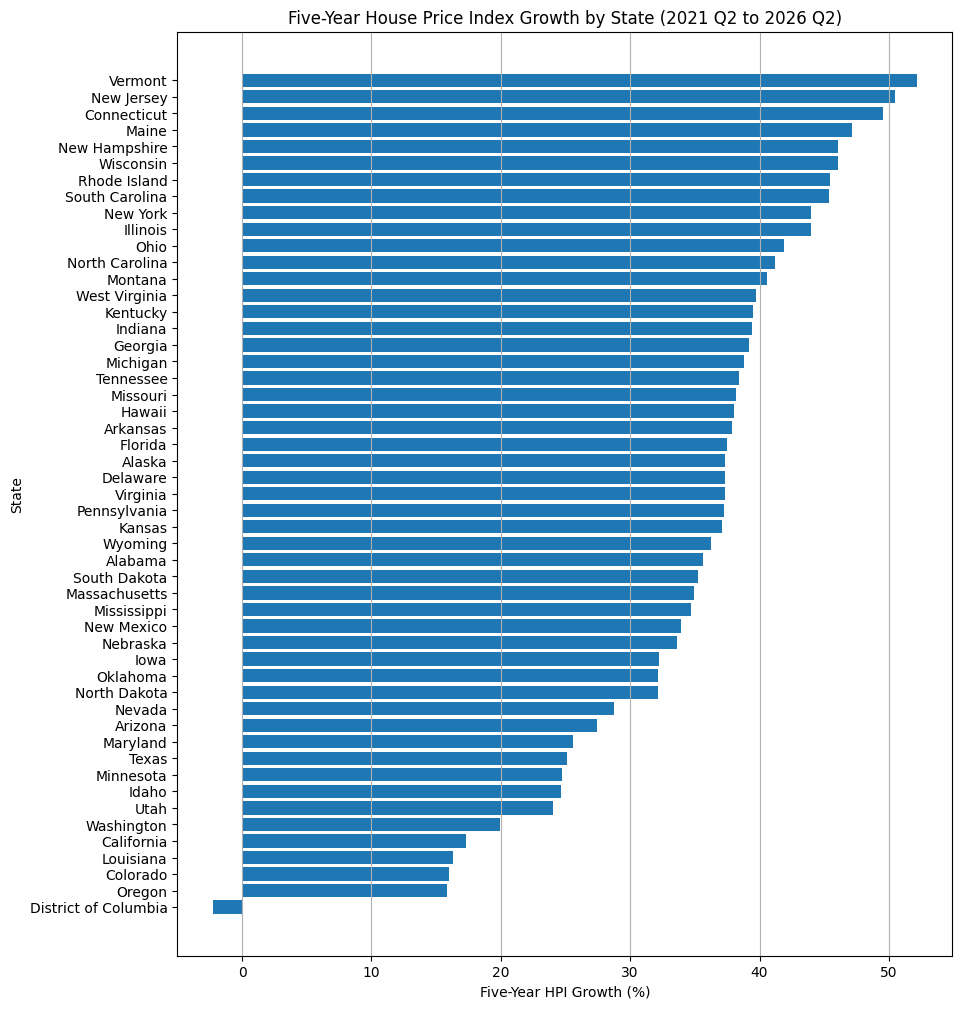

In [31]:
state_hpi = df[
    (df["hpi_type"] == "traditional") &
    (df["hpi_flavor"] == "purchase-only") &
    (df["frequency"] == "quarterly") &
    (df["level"] == "State")
].copy()

latest_year = state_hpi["yr"].max()

latest_period = state_hpi.loc[
    state_hpi["yr"] == latest_year,
    "period"
].max()

end = state_hpi[
    (state_hpi["yr"] == latest_year) &
    (state_hpi["period"] == latest_period)
][["place_name", "index_sa"]]

end = end.rename(columns={"index_sa": "end_hpi"})

start = state_hpi[
    (state_hpi["yr"] == latest_year - 5) &
    (state_hpi["period"] == latest_period)
][["place_name", "index_sa"]]

start = start.rename(columns={"index_sa": "start_hpi"})

growth_5yr = start.merge(end, on="place_name")

growth_5yr["five_year_growth_pct"] = (
    (growth_5yr["end_hpi"] / growth_5yr["start_hpi"]) - 1
) * 100

growth_5yr = growth_5yr.sort_values(
    "five_year_growth_pct",
    ascending=True
)

plt.figure(figsize=(10, 12))

plt.barh(
    growth_5yr["place_name"],
    growth_5yr["five_year_growth_pct"]
)

plt.title(
    f"Five-Year House Price Index Growth by State "
    f"({latest_year - 5} Q{latest_period} to {latest_year} Q{latest_period})"
)

plt.xlabel("Five-Year HPI Growth (%)")
plt.ylabel("State")
plt.grid(axis="x")

plt.show()

### Five-Year HPI Growth by State

The five-year comparison shows that house-price appreciation varies considerably across states. Some states experienced much stronger growth than others over the same period, showing that national housing trends are not experienced equally across geographic markets.

For a real estate investor, this highlights the importance of studying individual markets instead of relying only on national averages.

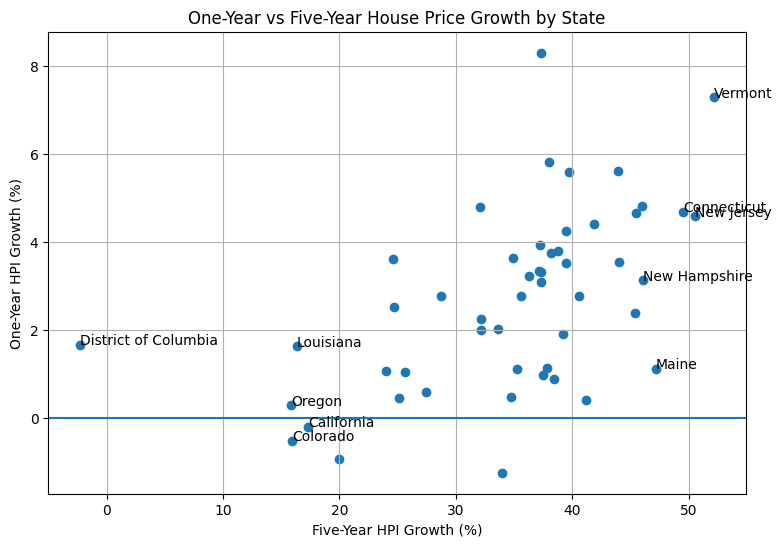

In [32]:
one_year_start = state_hpi[
    (state_hpi["yr"] == latest_year - 1) &
    (state_hpi["period"] == latest_period)
][["place_name", "index_sa"]]

one_year_start = one_year_start.rename(
    columns={"index_sa": "one_year_start_hpi"}
)

growth_compare = growth_5yr.merge(
    one_year_start,
    on="place_name"
)

growth_compare["one_year_growth_pct"] = (
    growth_compare["end_hpi"] /
    growth_compare["one_year_start_hpi"] - 1
) * 100

plt.figure(figsize=(9, 6))

plt.scatter(
    growth_compare["five_year_growth_pct"],
    growth_compare["one_year_growth_pct"]
)

for _, row in growth_compare.iterrows():

    if (
        row["five_year_growth_pct"] >
        growth_compare["five_year_growth_pct"].quantile(0.90)
        or
        row["five_year_growth_pct"] <
        growth_compare["five_year_growth_pct"].quantile(0.10)
    ):

        plt.annotate(
            row["place_name"],
            (
                row["five_year_growth_pct"],
                row["one_year_growth_pct"]
            )
        )

plt.title("One-Year vs Five-Year House Price Growth by State")

plt.xlabel("Five-Year HPI Growth (%)")
plt.ylabel("One-Year HPI Growth (%)")

plt.axhline(0)
plt.grid(True)

plt.show()

### One-Year vs. Five-Year HPI Growth by State

This comparison shows that strong long-term house-price appreciation does not always correspond with strong recent growth. Some states that experienced substantial five-year appreciation have slower one-year growth, while other markets have stronger recent momentum.

Looking at both short-term and long-term trends can therefore provide a more complete picture of housing-market performance.

# Part 3: Expanding Investment Knowledge

## Additional Dataset: Zillow Observed Rent Index (ZORI)

An additional dataset that would be useful for a real estate investor is the Zillow Observed Rent Index (ZORI). ZORI measures typical market rents across different geographic areas in the United States.

This dataset would be useful because property appreciation is only one part of a real estate investment. An investor who owns rental property would also care about how much rental income the property could generate and how rents are changing over time.

The FHFA House Price Index shows how residential property values have changed, while ZORI provides information about rental-market trends. Using the two datasets together could help an investor compare markets where home values are appreciating with markets where rents are also increasing.

Dataset Link: https://www.zillow.com/research/data/

# Conclusion

The FHFA House Price Index provides a useful way to examine changes in residential property values across the United States. The analysis shows that home prices have generally increased over time, but the amount of appreciation varies significantly across states and different time periods. Comparing one-year and five-year growth also shows that recent housing-market performance does not always follow longer-term trends.

While the House Price Index is useful for understanding property appreciation, it does not provide a complete picture of a real estate investment. Other factors such as rental income, interest rates, population growth, employment, and housing supply should also be considered. Combining FHFA house-price data with a dataset such as the Zillow Observed Rent Index could provide a more complete view of potential real estate markets.